### This notebook computes "VSB6. Theoretical hydroelectric potential" indicator for the 27 basins of IKI Project

**Spanish:** Potencial hidroelectrico teorico

**Created:** 10/10/2025 by Sophia Bakar (sbakar@rti.org) 
 
**Assumptions:** 

**Notes:** Calculated the hydraulic head in ArcGIS following these steps
1. reprojected DEM and flowlines to EPSG:32718
2. Used "generate points along lines" tool to create points along the flowline (100m apart). Output is a point layer with points along each flowline  
3. Used "Extract values to points" tool to get elevation at each point from DEM. Outputs points with a new field containing elevation
4. Calculated head (H) for each COMID by getting difference between max and min elevation along each flowline
5. Exported the results as a table with COMID and H_m columns

*In the H_m csv file, we constrain the values so that neither the min nor max can be less than 0

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
import rasterio
import re
import yaml
from pathlib import Path
from matplotlib import cm
from matplotlib.colors import ListedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import mapclassify

In [2]:
# set master path for input data from config file

config_path = Path("../../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

master_path = Path(config["master_path"])

In [3]:
subbasins_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_AHD_with_districts.shp"
db_path = master_path / "Indicadores" / "BD_RiesgoClimatico_IKI.db"
#wateralloc_db = master_path / "Modelacion" / "Grupos_Modelacion" / "Resultados" / "BalanceHidrico.sqlite"
wateralloc_db = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\Resultados\BalanceHidrico.sqlite"
catchments_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_catchment_modeling.shp"
flowlines_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_streamline_modeling.shp"   
hydraulic_head = master_path / "Indicadores" / "HydraulicHead.csv"

In [4]:
# set up indicator ID and get scenarios from database
IndID= 306 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

wa_map_df = pd.read_sql_query(
    """
    SELECT WaScnID, ScnID
    FROM WaScenarios
    ORDER BY WaScnID
    """,
    conn
)

conn.close()

wa_scenario_ids = wa_map_df['WaScnID'].tolist()

print("WaterALLOC Scenario Mapping:")
print(wa_map_df)


WaterALLOC Scenario Mapping:
   WaScnID  ScnID
0        1      2
1        3      1
2        4      1
3        7      3


In [5]:
flow_all = []

conn_wa = sqlite3.connect(wateralloc_db)

for wa_scn_id in wa_scenario_ids:
    print(f"\nProcessing WaScnID={wa_scn_id}")

    query_flow = """
    SELECT 
        a.comid AS COMID,
        AVG(
            a.[Oferta Entrada] 
          + a.[Oferta Local Sup] 
          + a.[Retorno]
          - a.[Dem Local Sup]
        ) AS Caudal_Medio,
        COUNT(*) AS n_months
    FROM "WAMSS_Balance por COMID (+Indice de estres)" AS a
    JOIN WAMMS_RunsInfo AS b 
        ON a.RunID = b.RunID
    WHERE b.WaScnID = ?
    GROUP BY a.comid
    """

    flow_df = pd.read_sql_query(query_flow, conn_wa, params=(wa_scn_id,))

    # Add WaScnID column
    flow_df['WaScnID'] = wa_scn_id

    flow_all.append(flow_df)

conn_wa.close()

flow_all_df = pd.concat(flow_all, ignore_index=True)
flow_all_df = flow_all_df[flow_all_df['COMID'].notna()].copy()
flow_all_df = flow_all_df.merge(wa_map_df, on='WaScnID', how='left')



Processing WaScnID=1

Processing WaScnID=3

Processing WaScnID=4

Processing WaScnID=7


In [6]:
# Step 1: monthly → yearly (still in 1000 m³/year)
flow_all_df['Caudal_Medio_cms'] = flow_all_df['Caudal_Medio'] * 12

# Step 2: convert 1000 m³ → m³
flow_all_df['Caudal_Medio_cms'] = flow_all_df['Caudal_Medio_cms'] * 1000

# Step 3: convert yearly → seconds
seconds_per_year = 365 * 24 * 3600

flow_all_df['Caudal_Medio_cms'] = flow_all_df['Caudal_Medio_cms'] / seconds_per_year

In [7]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
catchments_gdf = gpd.read_file(catchments_shapefile).to_crs('EPSG:32718')
flowlines_gdf = gpd.read_file(flowlines_shapefile).to_crs('EPSG:32718')
head_df = pd.read_csv(hydraulic_head)

In [8]:
# function to compute hydroelectric potential (PL) 
def compute_PL(Q, H, g=9.81):
    return g * Q * H * 1000 # where 1000 is the density of water in kg per cubic meter

In [9]:
# Base COMIDs from subbasins
base_comids = subbasins_gdf[['COMID']].drop_duplicates()
base_scenarios = wa_map_df[['ScnID']]

base_index = base_comids.merge(base_scenarios, how='cross')

In [10]:
# merge flow + head
pl_results = base_index.merge(
    flow_all_df,
    on=['COMID', 'ScnID'],
    how='left'
)

pl_results = pl_results.merge(
    head_df,
    on='COMID',
    how='left'
)

pl_results['H_m'] = pl_results['H_m'].astype(float)

# %%
# compute PL
pl_results['PL_W'] = np.where(
    pl_results[['Caudal_Medio_cms', 'H_m']].notna().all(axis=1),
    compute_PL(pl_results['Caudal_Medio_cms'], pl_results['H_m']),
    np.nan
)

# convert PL_W to MW
pl_results['PL_MW'] = pl_results['PL_W'] / 1e6

# constrain the minimum to 0
pl_results['PL_MW'] = pl_results['PL_MW'].clip(lower=0)

In [11]:
# Merge PL results with subbasins geometries for plotting
plot_gdf = subbasins_gdf[['COMID', 'geometry','Cuenca']].merge(
    pl_results,
    on='COMID',
    how='left'
)

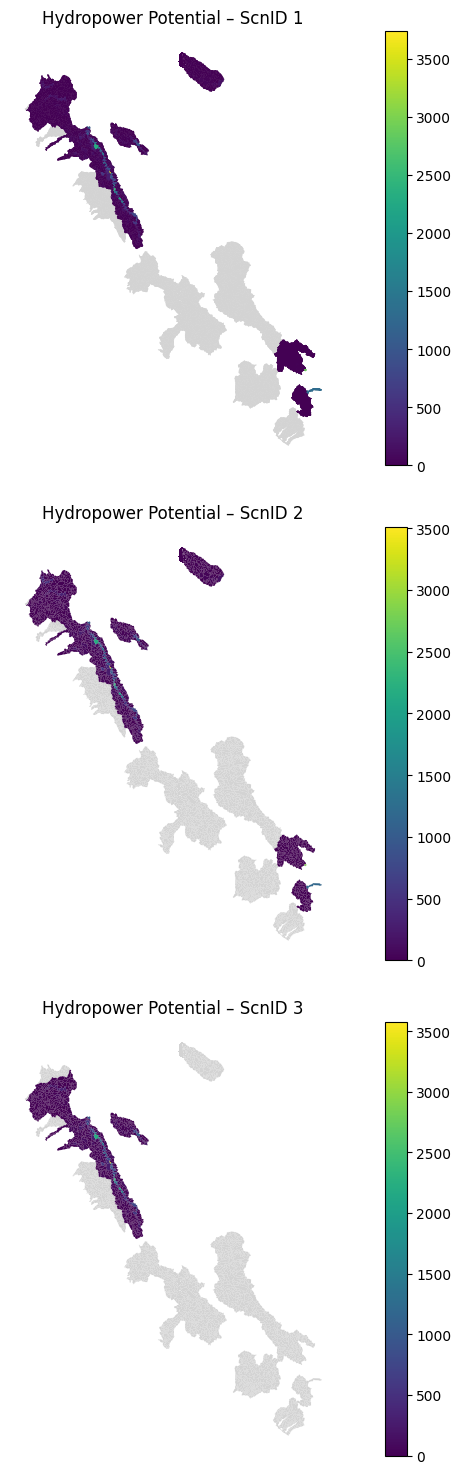

In [12]:
scenarios = sorted(plot_gdf['ScnID'].dropna().unique())

fig, axes = plt.subplots(len(scenarios), 1, figsize=(10, 5 * len(scenarios)))

if len(scenarios) == 1:
    axes = [axes]

for i, scn in enumerate(scenarios):
    ax = axes[i]
    data = plot_gdf[plot_gdf['ScnID'] == scn]

    data.plot(ax=ax, color='lightgrey', edgecolor='none')

    valid = data[data['PL_MW'].notna()]
    if not valid.empty:
        valid.plot(
            column='PL_MW',
            ax=ax,
            cmap='viridis',
            legend=True
        )

    ax.set_title(f"Hydropower Potential – ScnID {scn}")
    ax.axis('off')

plt.tight_layout()
plt.show()


C:\Users\sbakar\AppData\Local\Temp\ipykernel_27512\1387462348.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap('Blues')


Cuenca Alto Marañon: vmin=0, vmax=991.8987335831823 (95th percentile)


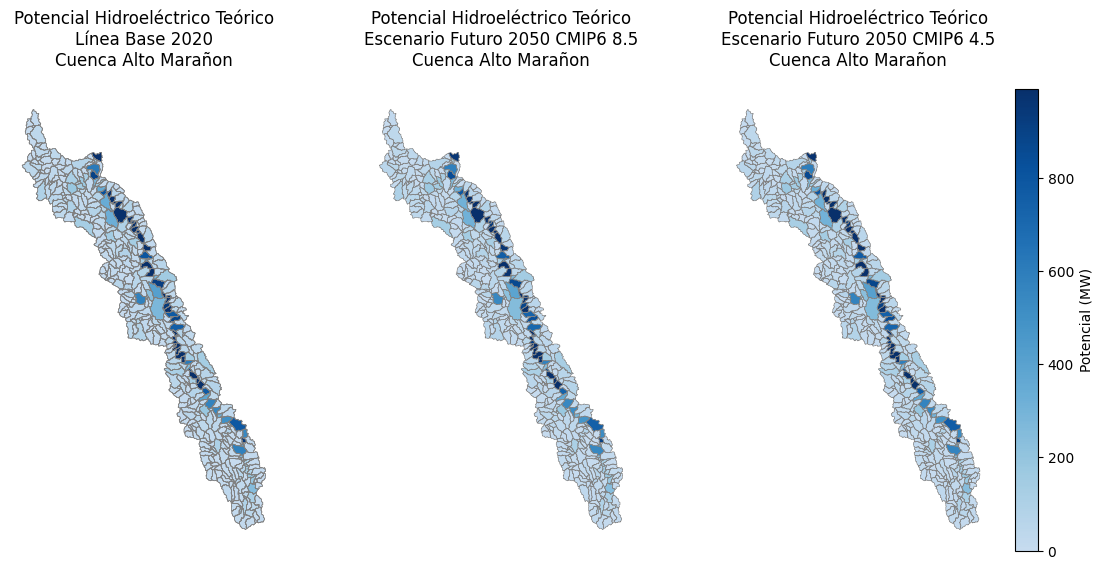

Saved: C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Indicador_VSB6_Mapas\Potencial_Hidroelectrico_Teorico_Cuenca_Alto_Maranon.png


In [15]:
target_cuencas = ['Cuenca Alto Marañon']

scenario_name_map = {
    1: 'Línea Base 2020',
    2: 'Escenario Futuro 2050 CMIP6 8.5',
    3: 'Escenario Futuro 2050 CMIP6 4.5'
}

output_dir = Path(r"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Indicador_VSB6_Mapas")
output_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------------
# COLORMAP (trim light colors)
# -----------------------------------
base_cmap = cm.get_cmap('Blues')
new_cmap = ListedColormap(base_cmap(np.linspace(0.25, 1, 256)))

# -----------------------------------
# LOOP THROUGH CUENCAS
# -----------------------------------

for cuenca_name in target_cuencas:

    subset_gdf = plot_gdf[plot_gdf['Cuenca'] == cuenca_name].copy()

    if subset_gdf.empty:
        print(f"Skipping {cuenca_name}: no data found")
        continue

    scenarios = sorted(subset_gdf['ScnID'].dropna().unique())

    if len(scenarios) == 0:
        print(f"Skipping {cuenca_name}: no scenarios found")
        continue

    # -----------------------------------
    # CUENCA-SPECIFIC COLOR SCALE
    # truncate upper end so mainstem values appear darker
    # -----------------------------------
    vmin = 0
    vmax = subset_gdf['PL_MW'].quantile(0.95)

    print(f"{cuenca_name}: vmin={vmin}, vmax={vmax} (95th percentile)")

    # -----------------------------------
    # CREATE FIGURE
    # -----------------------------------
    fig, axes = plt.subplots(1, len(scenarios), figsize=(5 * len(scenarios), 6))

    if len(scenarios) == 1:
        axes = [axes]

    # -----------------------------------
    # PLOT EACH SCENARIO
    # -----------------------------------
    for i, scn in enumerate(scenarios):
        ax = axes[i]
        data = subset_gdf[subset_gdf['ScnID'] == scn].copy()

        valid = data[data['PL_MW'].notna()].copy()

        if not valid.empty:
            valid.plot(
                column='PL_MW',
                ax=ax,
                cmap=new_cmap,
                vmin=vmin,
                vmax=vmax,
                edgecolor='none',
                legend=False
            )

        # Draw ALL subbasin boundaries
        data.boundary.plot(
            ax=ax,
            color='grey',
            linewidth=0.4
        )

        scenario_label = scenario_name_map.get(int(scn), f"Escenario {int(scn)}")

        ax.set_title(
            f"Potencial Hidroeléctrico Teórico\n{scenario_label}\n{cuenca_name}"
        )
        ax.axis('off')

    # -----------------------------------
    # ADJUST LAYOUT (reserve space for colorbar)
    # -----------------------------------
    plt.subplots_adjust(wspace=0.02, right=0.88)

    # -----------------------------------
    # ADD SHARED COLORBAR
    # -----------------------------------
    norm = Normalize(vmin=vmin, vmax=vmax)
    sm = ScalarMappable(norm=norm, cmap=new_cmap)
    sm._A = []

    cbar = fig.colorbar(
        sm,
        ax=axes,
        orientation='vertical',
        fraction=0.04,
        pad=0.02
    )

    cbar.set_label('Potencial (MW)')

    # -----------------------------------
    # SAVE FIGURE
    # -----------------------------------
    safe_cuenca_name = (
        cuenca_name
        .replace(" ", "_")
        .replace("-", "_")
        .replace("ñ", "n")
    )

    output_path = output_dir / f"Potencial_Hidroelectrico_Teorico_{safe_cuenca_name}.png"

    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved: {output_path}")

C:\Users\sbakar\AppData\Local\Temp\ipykernel_8112\1583724630.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap('Blues')


Cuenca Mayo: vmin=0, vmax=984.4746445678514


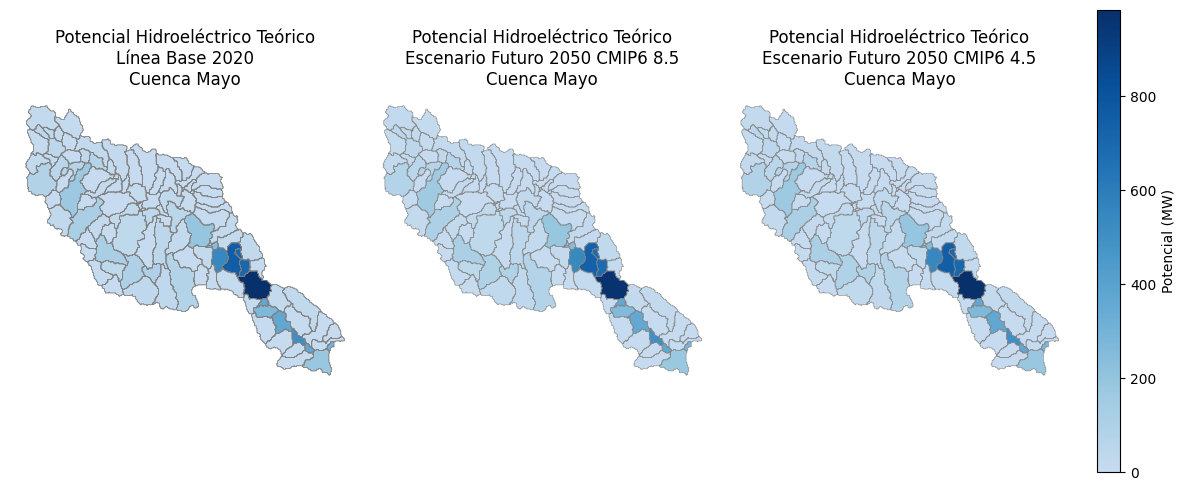

Saved: C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Indicador_VSB6_Mapas\Potencial_Hidroelectrico_Teorico_Cuenca_Mayo.png
Cuenca Chira: vmin=0, vmax=329.8593088222642


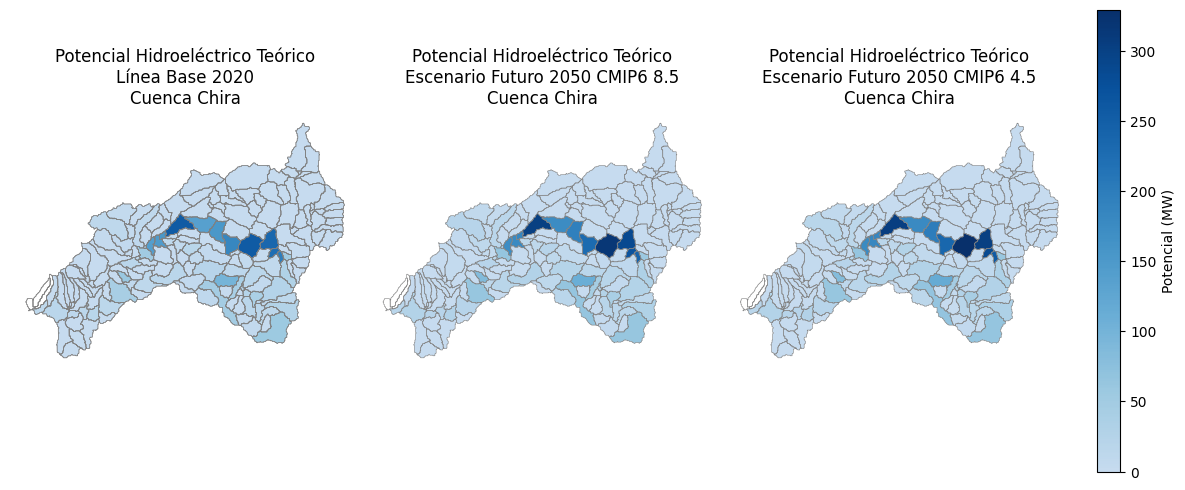

Saved: C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Indicador_VSB6_Mapas\Potencial_Hidroelectrico_Teorico_Cuenca_Chira.png
Cuenca Piura: vmin=0, vmax=34.63982310216849


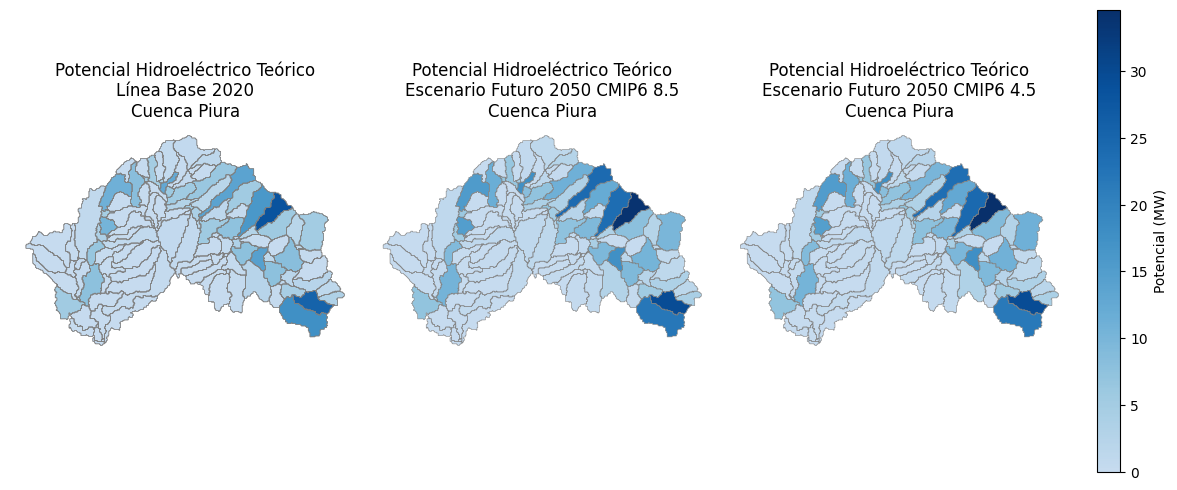

Saved: C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Indicador_VSB6_Mapas\Potencial_Hidroelectrico_Teorico_Cuenca_Piura.png
Cuenca Chancay-Lambayeque: vmin=0, vmax=261.87069623289113


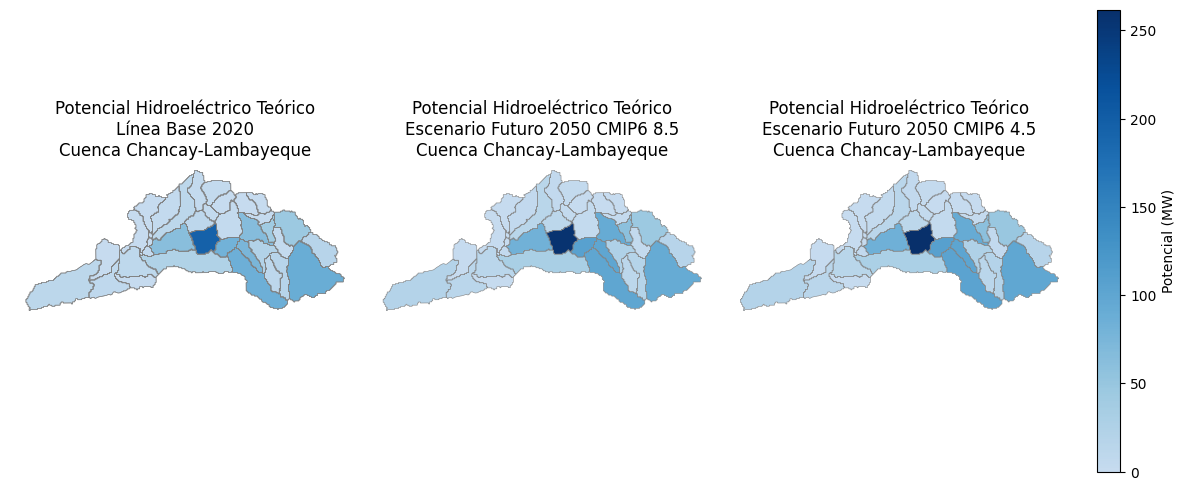

Saved: C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Indicador_VSB6_Mapas\Potencial_Hidroelectrico_Teorico_Cuenca_Chancay_Lambayeque.png
Cuenca Olmos: vmin=0, vmax=24.38349060466694


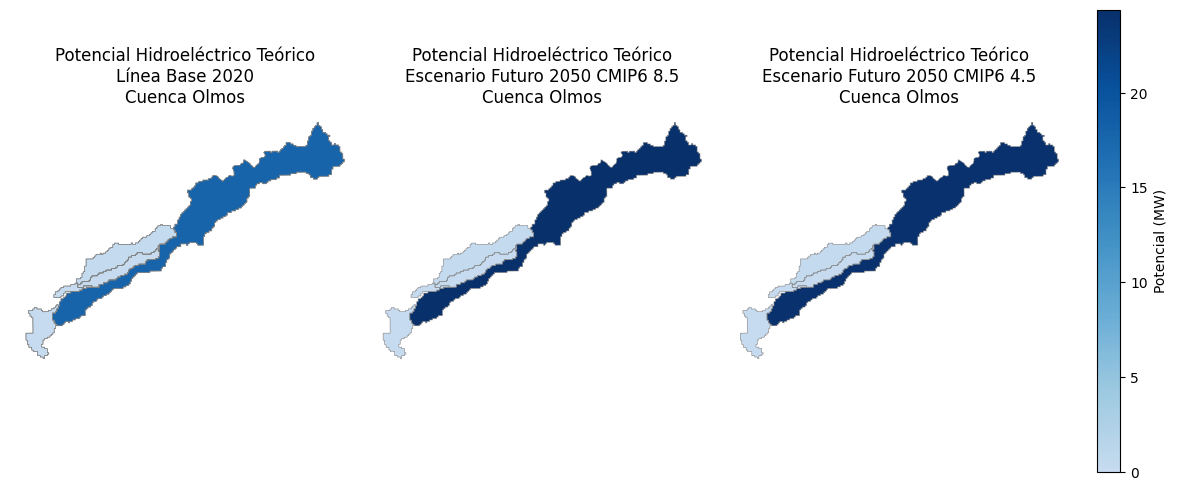

Saved: C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Indicador_VSB6_Mapas\Potencial_Hidroelectrico_Teorico_Cuenca_Olmos.png


In [13]:
target_cuencas = [
    'Cuenca Mayo',
    'Cuenca Chira',
    'Cuenca Piura',
    'Cuenca Chancay-Lambayeque',
    'Cuenca Olmos'
]

scenario_name_map = {
    1: 'Línea Base 2020',
    2: 'Escenario Futuro 2050 CMIP6 8.5',
    3: 'Escenario Futuro 2050 CMIP6 4.5'
}

output_dir = Path(r"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Indicador_VSB6_Mapas")
output_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------------
# COLORMAP (trim light colors)
# -----------------------------------
base_cmap = cm.get_cmap('Blues')
new_cmap = ListedColormap(base_cmap(np.linspace(0.25, 1, 256)))

# -----------------------------------
# LOOP THROUGH CUENCAS
# -----------------------------------

for cuenca_name in target_cuencas:

    subset_gdf = plot_gdf[plot_gdf['Cuenca'] == cuenca_name].copy()

    if subset_gdf.empty:
        print(f"Skipping {cuenca_name}: no data found")
        continue

    scenarios = sorted(subset_gdf['ScnID'].dropna().unique())

    if len(scenarios) == 0:
        print(f"Skipping {cuenca_name}: no scenarios found")
        continue

    # -----------------------------------
    # CUENCA-SPECIFIC COLOR SCALE
    # -----------------------------------
    vmin = 0
    vmax = subset_gdf['PL_MW'].max()

    print(f"{cuenca_name}: vmin={vmin}, vmax={vmax}")

    # -----------------------------------
    # CREATE FIGURE
    # -----------------------------------
    fig, axes = plt.subplots(1, len(scenarios), figsize=(5 * len(scenarios), 6))

    if len(scenarios) == 1:
        axes = [axes]

    # -----------------------------------
    # PLOT EACH SCENARIO
    # -----------------------------------
    for i, scn in enumerate(scenarios):
        ax = axes[i]
        data = subset_gdf[subset_gdf['ScnID'] == scn].copy()

        valid = data[data['PL_MW'].notna()].copy()

        if not valid.empty:
            valid.plot(
                column='PL_MW',
                ax=ax,
                cmap=new_cmap,
                vmin=vmin,
                vmax=vmax,
                edgecolor='none',
                legend=False
            )

        # Draw ALL subbasin boundaries
        data.boundary.plot(
            ax=ax,
            color='grey',
            linewidth=0.4
        )

        scenario_label = scenario_name_map.get(int(scn), f"Escenario {int(scn)}")

        ax.set_title(
            f"Potencial Hidroeléctrico Teórico\n{scenario_label}\n{cuenca_name}"
        )
        ax.axis('off')

    # -----------------------------------
    # ADJUST LAYOUT (reserve space for colorbar)
    # -----------------------------------
    plt.subplots_adjust(wspace=0.02, right=0.88)

    # -----------------------------------
    # ADD SHARED COLORBAR (no overlap)
    # -----------------------------------
    norm = Normalize(vmin=vmin, vmax=vmax)
    sm = ScalarMappable(norm=norm, cmap=new_cmap)
    sm._A = []

    cbar = fig.colorbar(
        sm,
        ax=axes,
        orientation='vertical',
        fraction=0.04,
        pad=0.02
    )

    cbar.set_label('Potencial (MW)')

    # -----------------------------------
    # SAVE FIGURE
    # -----------------------------------
    safe_cuenca_name = (
        cuenca_name
        .replace(" ", "_")
        .replace("-", "_")
        .replace("ñ", "n")
    )

    output_path = output_dir / f"Potencial_Hidroelectrico_Teorico_{safe_cuenca_name}.png"

    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved: {output_path}")

C:\Users\sbakar\AppData\Local\Temp\ipykernel_86728\3513746896.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap('Blues')


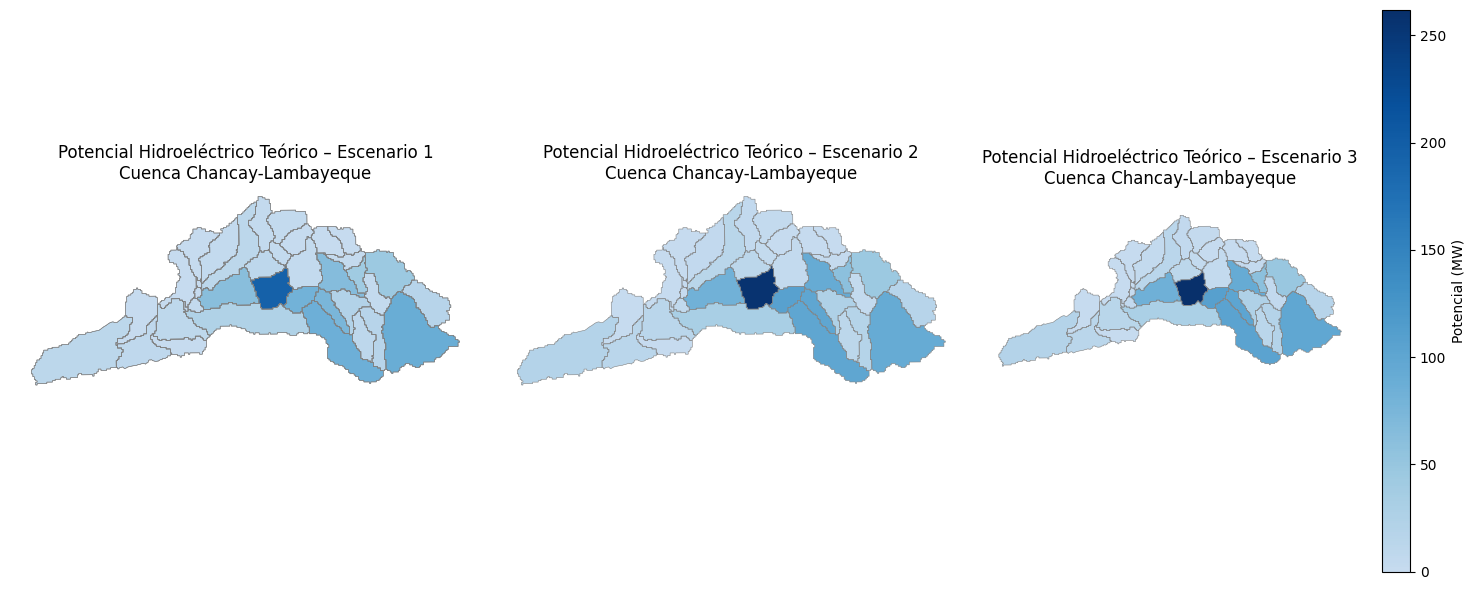

In [13]:
subset_gdf = plot_gdf[plot_gdf['Cuenca'] == 'Cuenca Chancay-Lambayeque'].copy()
scenarios = sorted(subset_gdf['ScnID'].dropna().unique())


# Trim colormap
base_cmap = cm.get_cmap('Blues')
new_cmap = ListedColormap(base_cmap(np.linspace(0.25, 1, 256)))

# Global scale
vmin = 0
vmax = subset_gdf['PL_MW'].max()

fig, axes = plt.subplots(1, len(scenarios), figsize=(5 * len(scenarios), 6))

if len(scenarios) == 1:
    axes = [axes]

for i, scn in enumerate(scenarios):
    ax = axes[i]
    data = subset_gdf[subset_gdf['ScnID'] == scn]

    # --- Filled polygons (NO edges) ---
    valid = data[data['PL_MW'].notna()]

    if not valid.empty:
        valid.plot(
            column='PL_MW',
            ax=ax,
            cmap=new_cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolor='none',
            legend=(i == len(scenarios) - 1),
            legend_kwds={'label': 'Potencial (MW)'}
        )

    # --- Add ALL subbasin boundaries on top ---
    data.boundary.plot(
        ax=ax,
        color='grey',
        linewidth=0.4
    )

    ax.set_title(
        f"Potencial Hidroeléctrico Teórico – Escenario {scn}\nCuenca Chancay-Lambayeque"
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

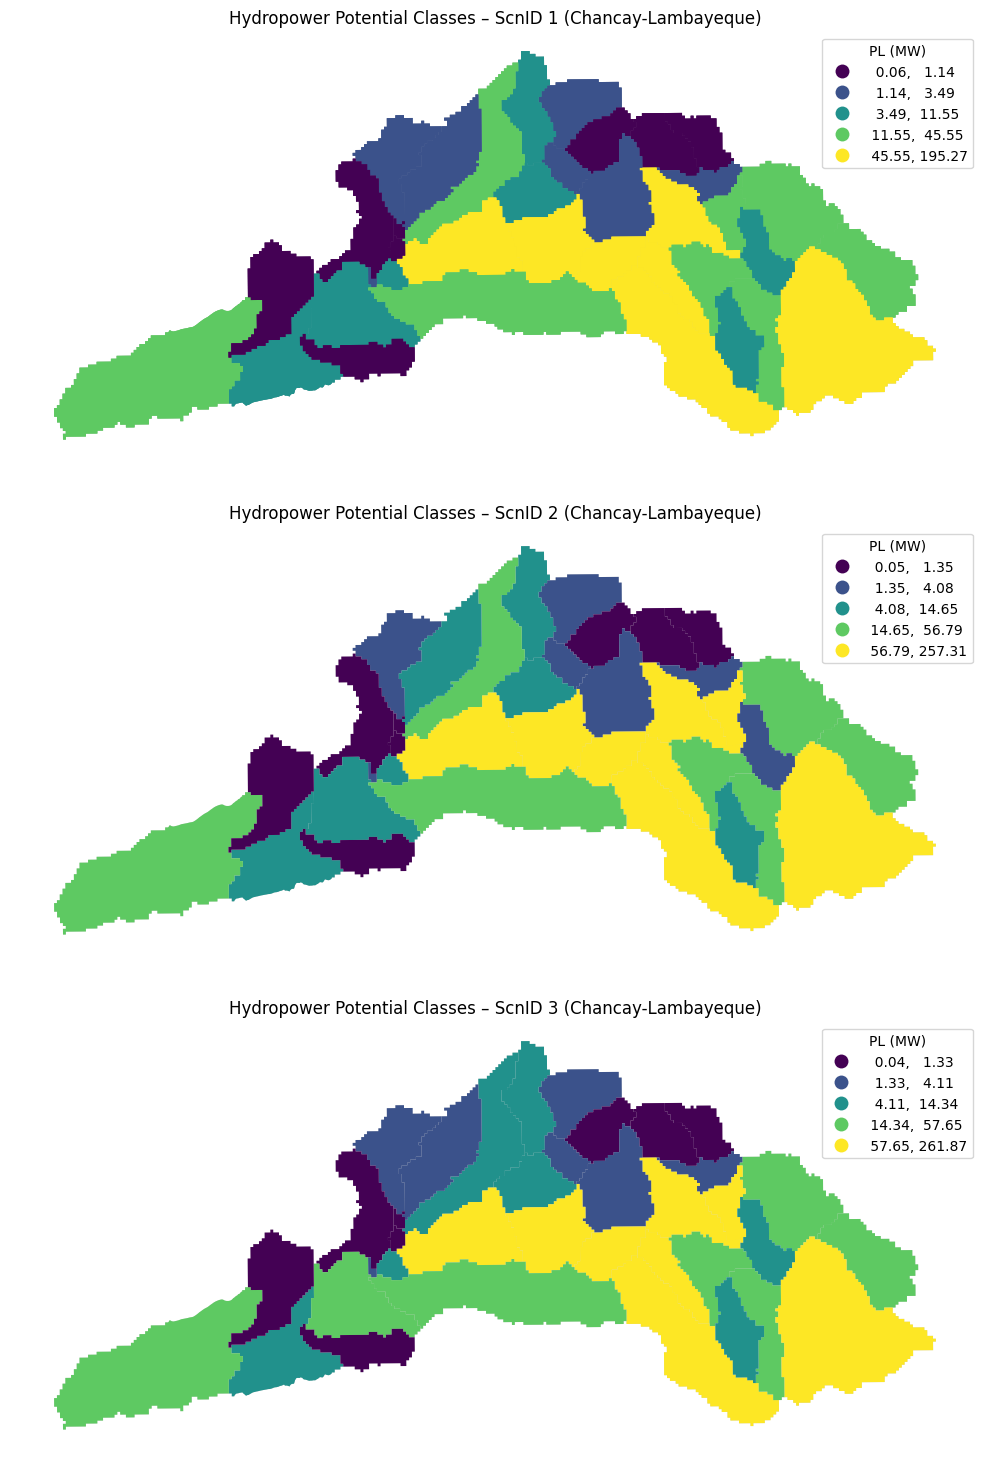

In [14]:
subset_gdf = plot_gdf[plot_gdf['Cuenca'] == 'Cuenca Chancay-Lambayeque'].copy()
scenarios = sorted(subset_gdf['ScnID'].dropna().unique())

fig, axes = plt.subplots(len(scenarios), 1, figsize=(10, 5 * len(scenarios)))

if len(scenarios) == 1:
    axes = [axes]

for i, scn in enumerate(scenarios):
    ax = axes[i]
    data = subset_gdf[subset_gdf['ScnID'] == scn].copy()

    data.plot(ax=ax, color='lightgrey', edgecolor='none')

    valid = data[data['PL_MW'].notna()].copy()

    if not valid.empty:
        valid.plot(
            column='PL_MW',
            ax=ax,
            cmap='viridis',
            legend=True,
            scheme='Quantiles',
            k=5,
            edgecolor='none',
            legend_kwds={'title': 'PL (MW)'}
        )

    ax.set_title(f"Hydropower Potential Classes – ScnID {scn} (Chancay-Lambayeque)")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [14]:
comid_check = 305601900

check_df = (
    pl_results
    .loc[pl_results['COMID'] == comid_check,
         ['ScnID', 'Caudal_Medio_cms', 'H_m', 'PL_MW']]
    .drop_duplicates(subset=['ScnID'])
    .sort_values('ScnID')
)

print(check_df)

      ScnID  Caudal_Medio_cms          H_m      PL_MW
1859      1          1.450336  1137.720047  16.187253
1858      2          2.113914  1137.720047  23.593467
1861      3          2.189383  1137.720047  24.435782


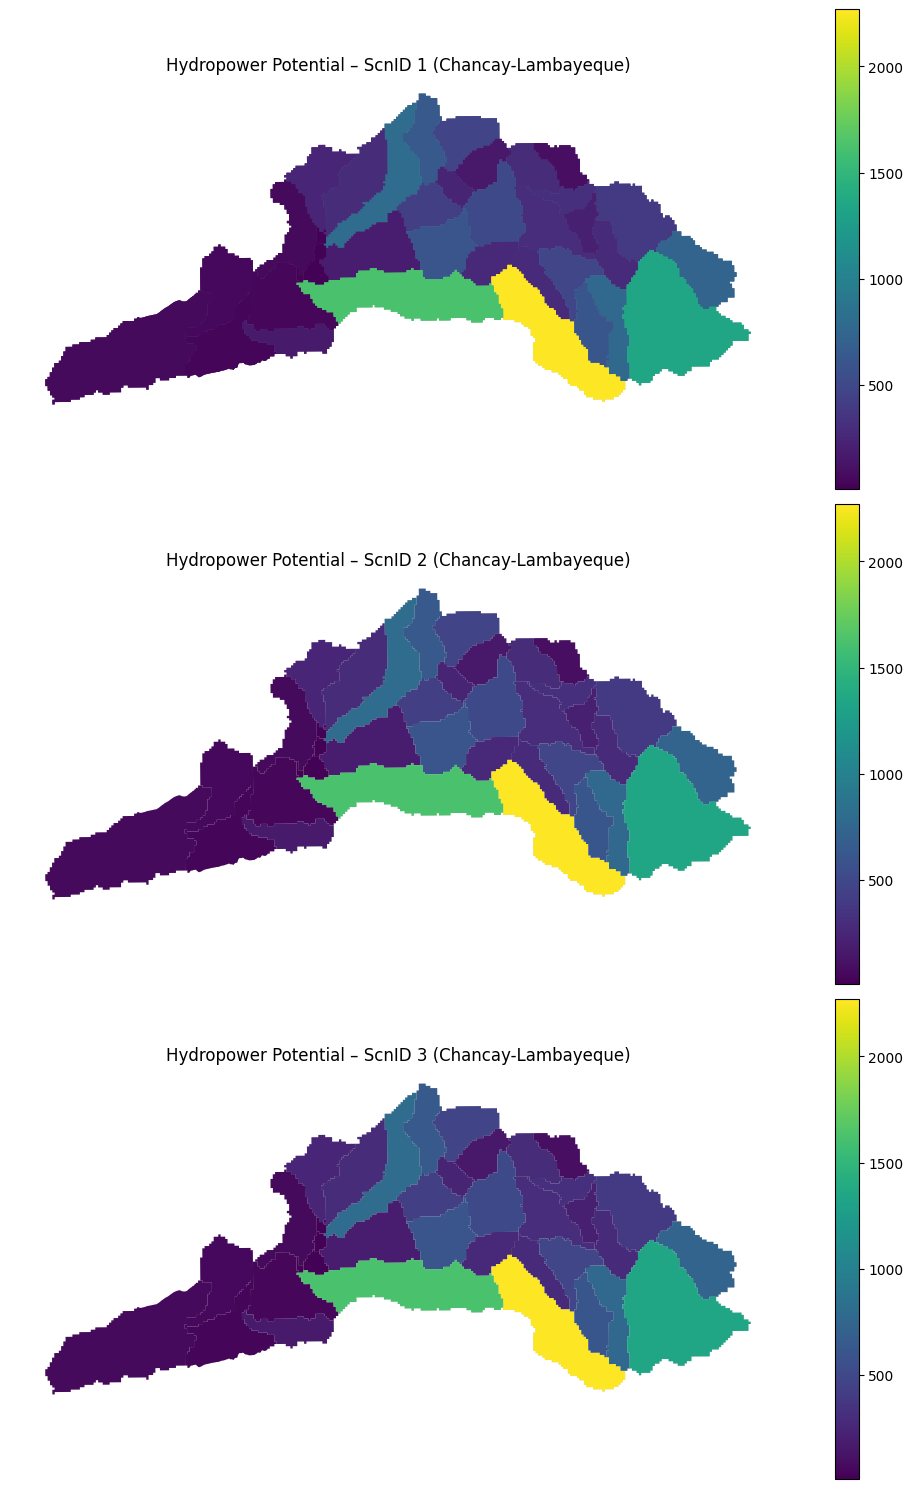

In [16]:
subset_gdf = plot_gdf[plot_gdf['Cuenca'] == 'Cuenca Chancay-Lambayeque'].copy()
scenarios = sorted(subset_gdf['ScnID'].dropna().unique())

fig, axes = plt.subplots(len(scenarios), 1, figsize=(10, 5 * len(scenarios)))

if len(scenarios) == 1:
    axes = [axes]

for i, scn in enumerate(scenarios):
    ax = axes[i]
    data = subset_gdf[subset_gdf['ScnID'] == scn]

    data.plot(ax=ax, color='lightgrey', edgecolor='none')

    valid = data[data['H_m'].notna()]
    if not valid.empty:
        valid.plot(
            column='H_m',
            ax=ax,
            cmap='viridis',
            legend=True
        )

    ax.set_title(f"Hydropower Potential – ScnID {scn} (Chancay-Lambayeque)")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
pl_results_unique = pl_results.drop_duplicates(subset=['COMID', 'ScnID']).reset_index(drop=True)

In [14]:
insert_data = pl_results_unique.copy()
value_column = 'PL_MW'

# Connect to SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

rows_to_insert = []

for _, row in insert_data.iterrows():
    scn_id = row['ScnID']
    comid = row['COMID']
    value = row[value_column]

    # Skip rows without scenario or value
    if pd.isna(scn_id) or pd.isna(value):
        continue

    rows_to_insert.append((
        int(scn_id),
        IndID,
        int(comid),
        float(value)
    ))

# Insert query
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [15]:
# Check indicator limits
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

# Print stats by scenario
value_stats_by_scenario = (
    pl_results_unique
    .groupby('ScnID')['PL_MW']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== PL_W values by scenario ===")
print(value_stats_by_scenario)

# Check for duplicates in rows_to_insert
df_check = pd.DataFrame(
    rows_to_insert,
    columns=['ScnID', 'IndID', 'COMID', 'Value']
)

duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])

print("\nDuplicates in rows_to_insert (should be empty):")
print(df_check[duplicates])


Indicator 306  Min: 0, Max: 3919.733991952346

=== PL_W values by scenario ===
   ScnID  min          max  count
0      1  0.0  3733.079992   1498
1      2  0.0  3513.505502   1498
2      3  0.0  3579.915032    960

Duplicates in rows_to_insert (should be empty):
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [16]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()